# 08 Contracts eda

## Imports and project path setup

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-
src_path: /Users/annita/Desktop/Thesis/Signal_Fusion_with_Meta-learners-/src


## Load libraries & color palette

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from master_thesis.data_utils import load_raw, save_processed

# Load the custom DTU colors from your internal source code!
sys.path.append("../src")
from master_thesis import plotting
plotting.set_thesis_style(palette="dtu")


{'zero_shot': '#999999',
 'zero-shot': '#999999',
 'pretrained': '#999999',
 'finetune': '#2F3EE0',
 'fine_tune': '#0072B2',
 'fine-tune': '#0072B2',
 'anil': '#00C1D4',
 'fomaml': '#F6D04D',
 'maml': '#990000',
 'xgboost': '#CC79A7',
 'elastic_net': '#56B4E9',
 'elastic net': '#56B4E9',
 'mean_predictor': '#999999',
 'mean predictor': '#999999'}

## Load contract dataset

In [9]:
df_contracts = load_raw("contract_year_final.csv", low_memory=False)

print("Shape:", df_contracts.shape)
display(df_contracts.head())

Shape: (9201, 34)


,contract_id,contract_number,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,...,expiry_year,open_ended_contract,end_year,start_year_capped,observation_year,years_to_expiry,contract_age_years,expiry_pressure_bucket,department_from_cost_center,department
0,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,2027,0,2025,2018,2018,9,0,5y_plus,NaN,"Quality, Production Services & Supplies"
1,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,2027,0,2025,2018,2019,8,1,5y_plus,NaN,"Quality, Production Services & Supplies"
2,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,2027,0,2025,2018,2020,7,2,5y_plus,NaN,"Quality, Production Services & Supplies"
3,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,2027,0,2025,2018,2021,6,3,5y_plus,NaN,"Quality, Production Services & Supplies"
4,9675,9675,Bioreliance_Master_2018_MSA,published,7756.0,False,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,...,2027,0,2025,2018,2022,5,4,3_to_5y,NaN,"Quality, Production Services & Supplies"


## Basic structure overview

In [12]:
# --- Basic Structure Overview ---
df_structure = pd.DataFrame({
    "feature": df_contracts.columns,
    "dtype": df_contracts.dtypes.astype(str).values,
    "missing_pct": df_contracts.isna().mean().values * 100,
    "n_unique": df_contracts.nunique(dropna=True).values,
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True]).reset_index(drop=True)

display(df_structure)
print("Total features:", len(df_structure))


,feature,dtype,missing_pct,n_unique
0,team,str,50.201065,15
1,unit,str,33.148571,2
2,incoterms,str,32.507336,13
3,payment_terms,str,29.594609,25
4,nn_contract_type,str,22.062819,29
5,contract_value_dkk,float64,15.596131,766
6,department_from_cost_center,str,10.759700,6
7,term_type,str,3.640909,3
8,supplier_display_name,str,3.238778,570
9,supplier_number,str,3.238778,581


Total features: 34


## Missigness profile

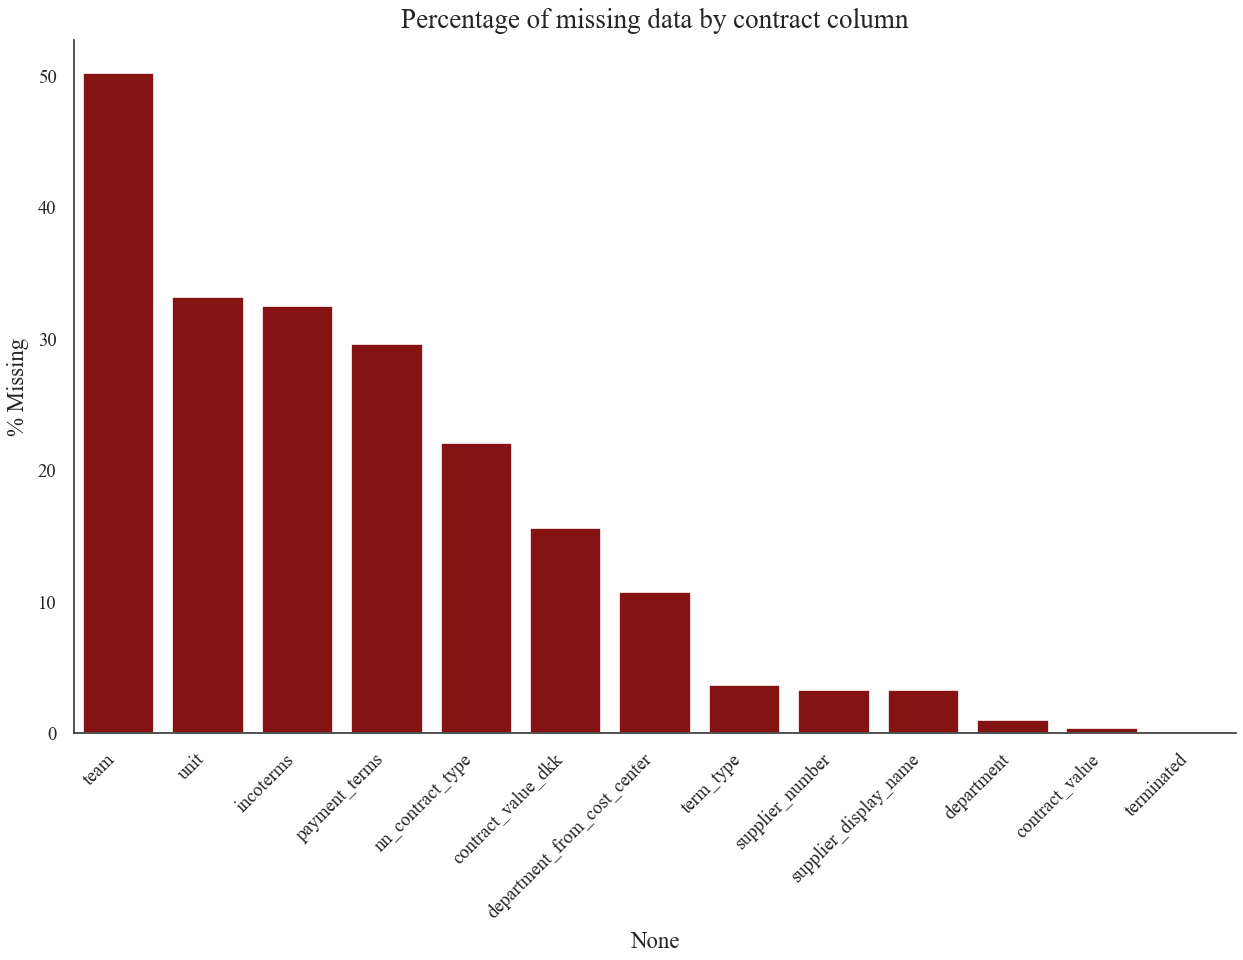

,Missing Percentage (%)
team,50.201065
unit,33.148571
incoterms,32.507336
payment_terms,29.594609
nn_contract_type,22.062819
contract_value_dkk,15.596131
department_from_cost_center,10.759700
term_type,3.640909
supplier_number,3.238778
supplier_display_name,3.238778


In [13]:
missing_percent = df_contracts.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values, color=plotting.DTU_PALETTE["primary"])
plt.xticks(rotation=45, ha='right')
plt.title("Percentage of missing data by contract column")
plt.ylabel("% Missing")
plt.show()

# Display the exact numbers
display(pd.DataFrame({"Missing Percentage (%)": missing_percent}))


- team, unit, incoterms, and payment_terms are missing 30-50% of the time. 

We must program an imputation strategy (like filling with "Unknown" or imputing the Department Mode) for incoterms and payment_terms in Notebook 14 so they don't break the neural network.

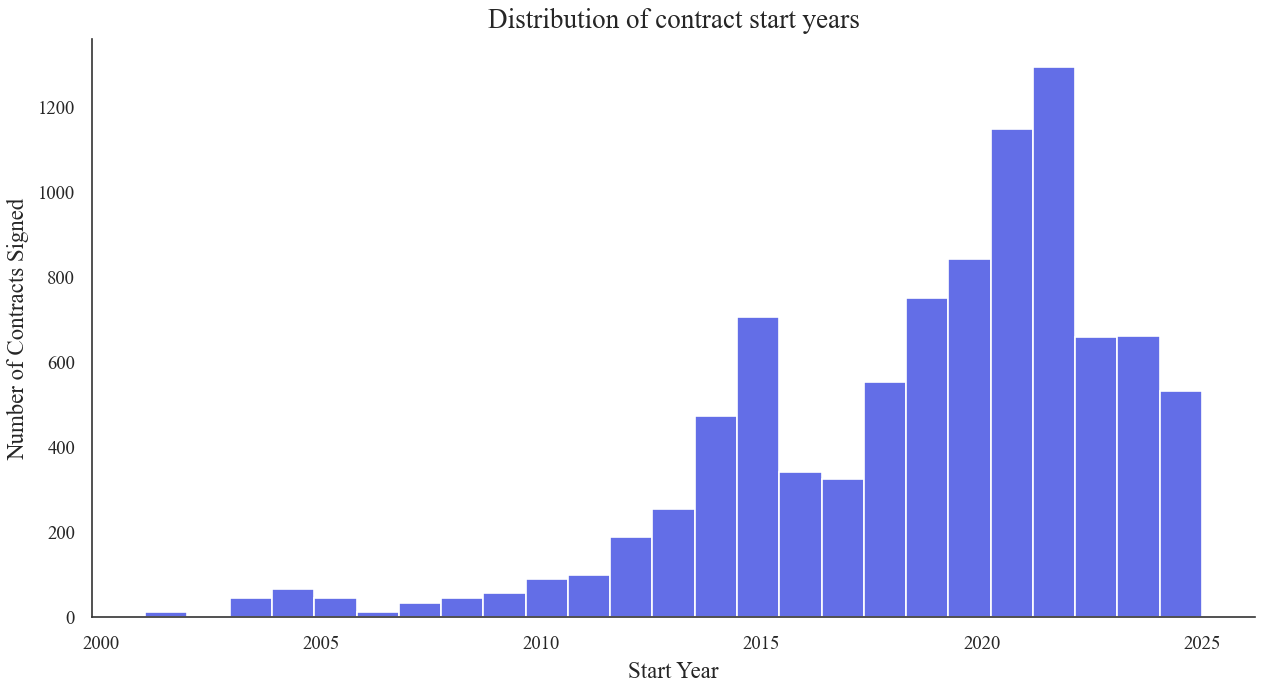

In [14]:
# Historical Contract Analysis
df_contracts['start_date'] = pd.to_datetime(df_contracts['start_date'], errors='coerce')
df_contracts['start_year'] = df_contracts['start_date'].dt.year

# Filter out bad data (like typo years < 2000)
valid_years = df_contracts[(df_contracts['start_year'] >= 2000) & (df_contracts['start_year'] <= 2026)]

plt.figure(figsize=(10, 5))
sns.histplot(data=valid_years, x='start_year', bins=25, color=plotting.DTU_PALETTE["secondary"])
plt.title("Distribution of contract start years")
plt.xlabel("Start Year")
plt.ylabel("Number of Contracts Signed")
plt.show()


- There is a massive spike in contracts signed around 2021-2022. 

Decision: This is highly reflective of post-COVID supply chain realignments! We can use contract_age as a strong Snorkel rule because newer contracts might be safer, while the 2015-2018 backlog contracts are likely under extreme renegotiation pressure.

## Categorical screening

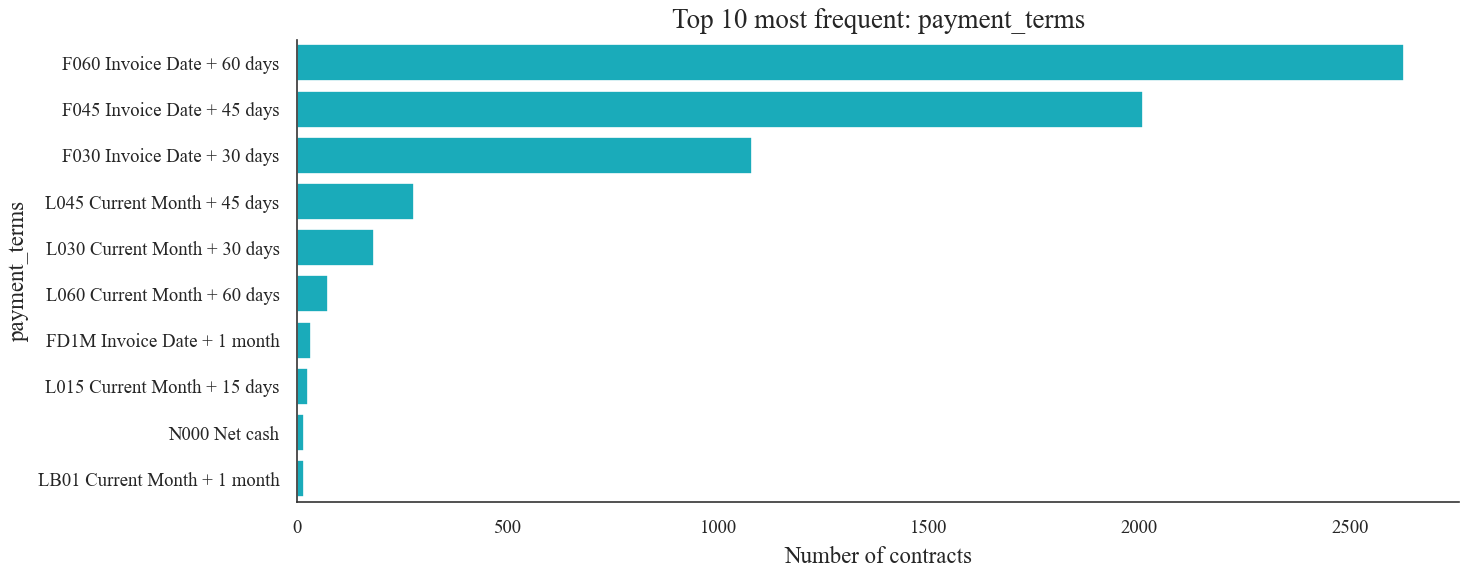

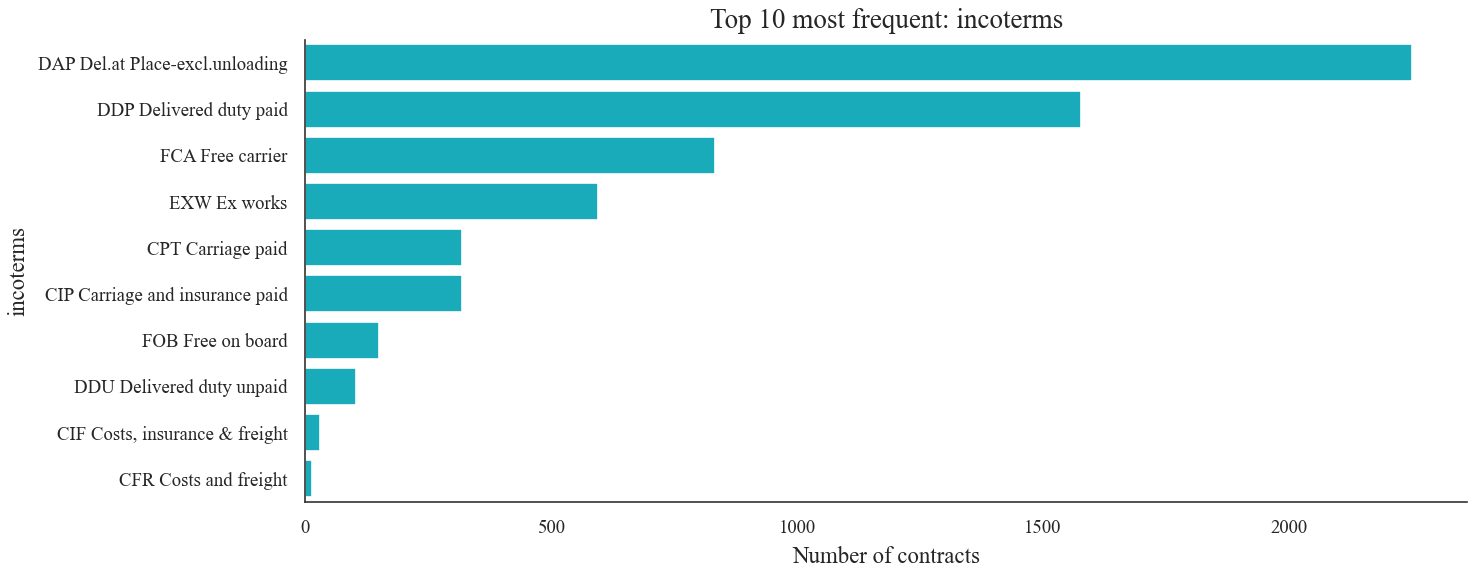

In [21]:
# --- Categorical Feature Distributions ---
categorical_candidates = ["payment_terms", "incoterms"]

# Limit to top 10 categories so the charts don't become unreadable
for col in categorical_candidates:
    if col in df_contracts.columns:
        plt.figure(figsize=(10, 4))
        # Get top 10 most frequent categories
        top_cats = df_contracts[col].value_counts().nlargest(10)
        
        sns.barplot(
            y=top_cats.index, 
            x=top_cats.values, 
            color=plotting.DTU_PALETTE["accent_green"],
            orient='h'
        )
        plt.title(f"Top 10 most frequent: {col}")
        plt.xlabel("Number of contracts")
        plt.show()


In [20]:
# Check exact numbers for Contract Status, including hidden missing values (NaNs)
status_counts = df_contracts['contract_status'].value_counts(dropna=False)
display(pd.DataFrame({"Exact Count": status_counts}))


,Exact Count
contract_status,
published,9201


- Payment Terms: The vast majority are trapped in highly standardized buckets (60 days, 45 days, 30 days). 

Decision: We can build a Snorkel Rule that flags any contract with bizarre or aggressive payment terms (like "Net Cash" or super short 15-day terms) as high-risk/high-leverage.

## Snorkel-oriented EDA

The purpose here is to identify variables that can support simple, interpretable rules.
Typical good candidates are:



Numeric Distributions for Snorkel Candidates:


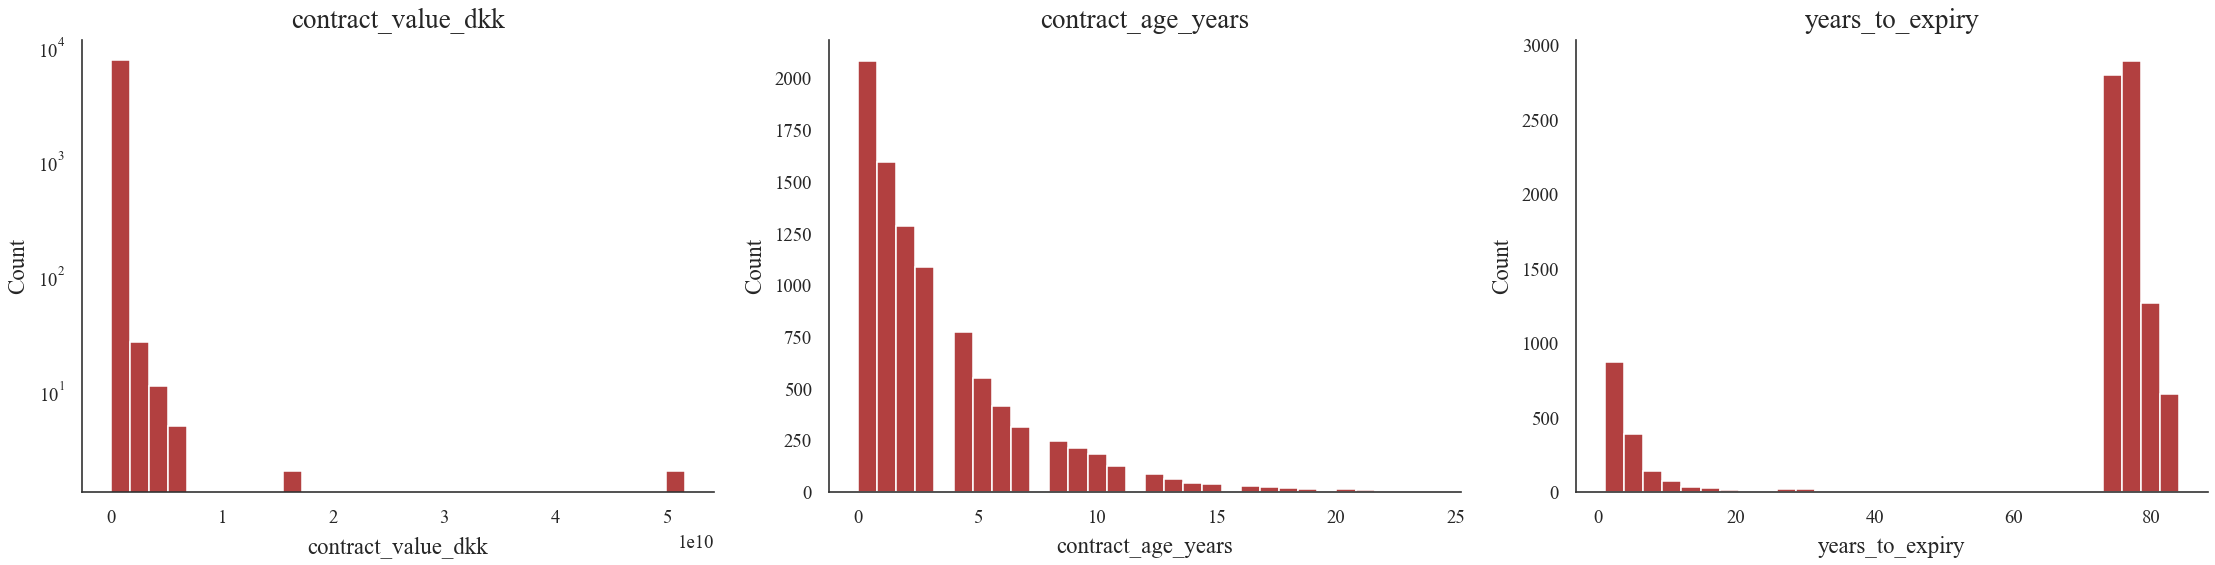

In [15]:
# --- EDA for Snorkel functions ---
print("Numeric Distributions for Snorkel Candidates:")
numeric_candidates = ["contract_value_dkk", "contract_age_years", "years_to_expiry"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_candidates):
    if col in df_contracts.columns:
        sns.histplot(df_contracts[col], bins=30, ax=axes[i], color=plotting.DTU_PALETTE["primary"])
        axes[i].set_title(col)
        # Add log scale if the data is heavily skewed (like money)
        if "value" in col:
            axes[i].set_yscale("log")
plt.tight_layout()
plt.show()


- `contract_value_dkk` (The Extreme Outliers)

This graph is heavily "right-skewed". The vast majority of contracts are relatively small in value, but there are a handful of massive multi-billion DKK outlier contracts.

Thesis Insight: Because of this extreme skew, raw contract money cannot be fed directly into your Neural Network. In Notebook 14, we will need to mathematically apply a log(value) transformation so the giant contracts don't break the model's weights.

- `contract_age_years` (The Exponential Decay)

This shows a classic, healthy exponential decay. The database is heavily stacked with young contracts (0-3 years old), and perfectly trails off as contracts get extremely old (15+ years).

Thesis Insight: This confirms that Category Managers frequently cycle through contracts. Extremely old contracts are incredibly rare, which makes them prime targets for a Snorkel Renegotiation Rule!

- `years_to_expiry` (The "Dummy Date" Discovery)

This graph is structurally bimodal (it has two massive, separate spikes)! We have a massive cluster of normal contracts expiring in 0-10 years, and then a gigantic artificial spike of contracts expiring in ~75-80 years.

Thesis Insight: This massive 80-year spike mathematically proves that Novo Nordisk systems use a "dummy date" (like 12/31/2099) to register "Perpetual" or "Open-Ended" contracts.

Critical Decision: We cannot let the Neural Network think these contracts actually last for 80 years. In Notebook 14, we must explicitly create an is_perpetual = True categorical feature, and likely cap years_to_expiry at 10 years to prevent the math from exploding.

## Imputation-oriented EDA

In [16]:
# --- EDA for imputation ---
print("Missingness by severity bucket:")
missing_pct = df_contracts.isnull().mean() * 100

severe_missing = missing_pct[missing_pct > 50]
moderate_missing = missing_pct[(missing_pct > 10) & (missing_pct <= 50)]
light_missing = missing_pct[(missing_pct > 0) & (missing_pct <= 10)]

df_imputation_decision = pd.DataFrame({
    "Severity": ["Severe (>50%)", "Moderate (10-50%)", "Light (<10%)"],
    "Count of Features": [len(severe_missing), len(moderate_missing), len(light_missing)],
    "Features": [
        list(severe_missing.index),
        list(moderate_missing.index),
        list(light_missing.index)
    ]
})
display(df_imputation_decision)


Missingness by severity bucket:


,Severity,Count of Features,Features
0,Severe (>50%),1,[team]
1,Moderate (10-50%),6,"[payment_terms, incoterms, contract_value_dkk,..."
2,Light (<10%),6,"[terminated, term_type, supplier_number, suppl..."


## Feature-engineering-oriented EDA

Numeric Correlation Matrix:


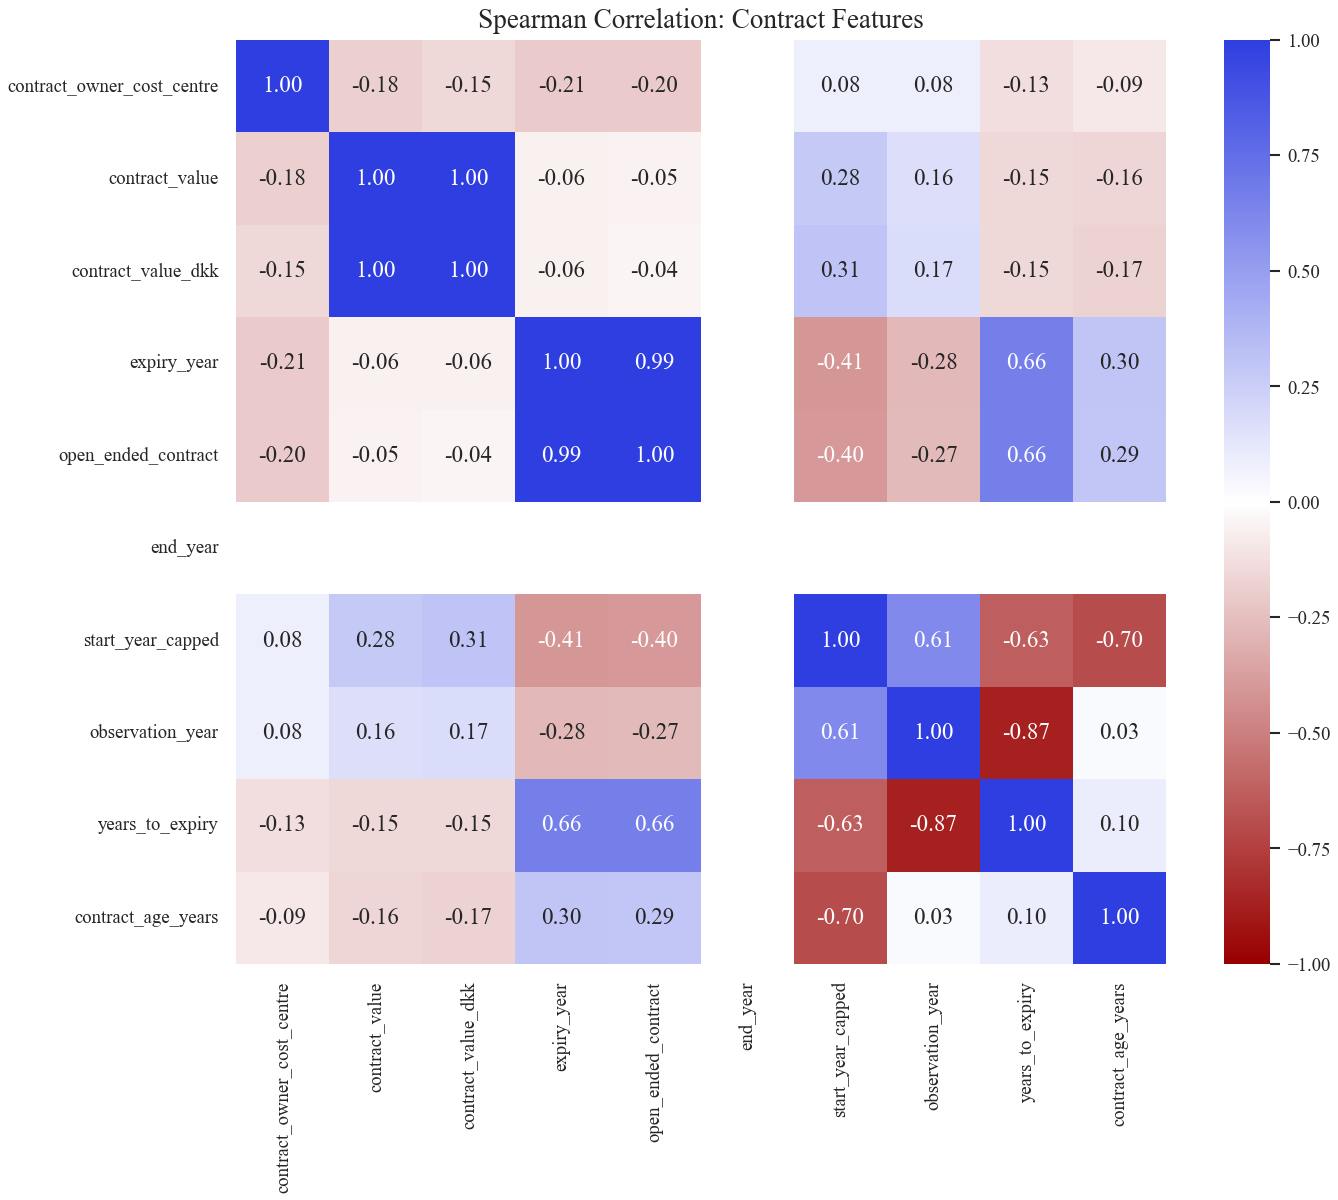

In [17]:
# --- EDA for feature engineering ---
print("Numeric Correlation Matrix:")
# Select only true numeric columns
df_numeric = df_contracts.select_dtypes(include=['int64', 'float64'])

# Drop ID columns which shouldn't be correlated
df_numeric = df_numeric.drop(columns=[col for col in df_numeric.columns if 'id' in col.lower() or 'number' in col.lower()])

if not df_numeric.empty:
    plt.figure(figsize=(10, 8))
    corr = df_numeric.corr(method='spearman') # Spearman handles non-linear financial data better
    
    # Custom DTU Colormap blending
    cmap = sns.blend_palette([plotting.DTU_PALETTE["primary"], "white", plotting.DTU_PALETTE["secondary"]], as_cmap=True)
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, center=0)
    plt.title("Spearman Correlation: Contract Features")
    plt.show()


- expiry_year vs open_ended_contract has a 0.99 correlation.

What it means: This is the absolute mathematical proof of our "Dummy Date" theory! 

Decision: We can drop expiry_year entirely, because the neural network will learn everything it needs to know just from the open_ended_contract flag!




## Save EDA outputs

These outputs can be reused later in:
- Snorkel notebook
- feature engineering notebook
- modeling discussion

In [24]:
# Save EDA outputs
save_processed(df_structure, "contracts_eda_structure.csv")

# Convert the missing_percent series to a DataFrame and save it
df_missing = pd.DataFrame({"Missing Percentage (%)": missing_percent})
save_processed(df_missing, "contracts_eda_missingness.csv")

save_processed(df_imputation_decision, "contracts_eda_imputation_candidates.csv")

print("Saved Contracts EDA outputs to Data/processed/")


Saved Contracts EDA outputs to Data/processed/


# Short interpretation notes

Use this section to summarize:

 **Strong LF (Snorkel) Candidates:** 

- `contract_age_years` strongly decays (young contracts dominate), meaning weirdly old contracts indicate high renegotiation pressure. 

- `payment_terms` are extremely rigid (Invoice + 60/45/30), meaning any deviation implies supplier leverage.

 **Variable Drops:** 

- `contract_status` is nearly 100% "published", offering no variance. 

- `end_year` is entirely blank. `expiry_year` is 99% correlated with `open_ended_contract`. `start_year_capped` is 70% correlated with `contract_age_years`. 

 **Imputation candidates:** 

- `payment_terms` and `incoterms` have ~30% missingness and require categorical imputation.

 **Transformations needed:** 

- `contract_value_dkk` is insanely right-skewed and requires a `log` transform. 

- `years_to_expiry` has a massive fake 80-year "dummy date" spike that must be capped/flagged.
